In [1]:
print("HW2")

HW2


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
print("Q_b")

Q_b


In [4]:
df = pd.read_excel("CCPP/Folds5x2_pp.xlsx")

print(df.shape)

print(df.head(10))

(9568, 5)
      AT      V       AP     RH      PE
0  14.96  41.76  1024.07  73.17  463.26
1  25.18  62.96  1020.04  59.08  444.37
2   5.11  39.40  1012.16  92.14  488.56
3  20.86  57.32  1010.24  76.64  446.48
4  10.82  37.50  1009.23  96.62  473.90
5  26.27  59.44  1012.23  58.77  443.67
6  15.89  43.96  1014.02  75.24  467.35
7   9.48  44.71  1019.12  66.43  478.42
8  14.64  45.00  1021.78  41.25  475.98
9  11.74  43.56  1015.14  70.72  477.50


In [5]:
print("There are 9568 rows and 5 columns in the dataset. Each row represents one hourly operating record of the power plant. \nThe columns represent four environmental factors (AT, V, AP, RH) and the corresponding net electrical power output (PE).")

There are 9568 rows and 5 columns in the dataset. Each row represents one hourly operating record of the power plant. 
The columns represent four environmental factors (AT, V, AP, RH) and the corresponding net electrical power output (PE).


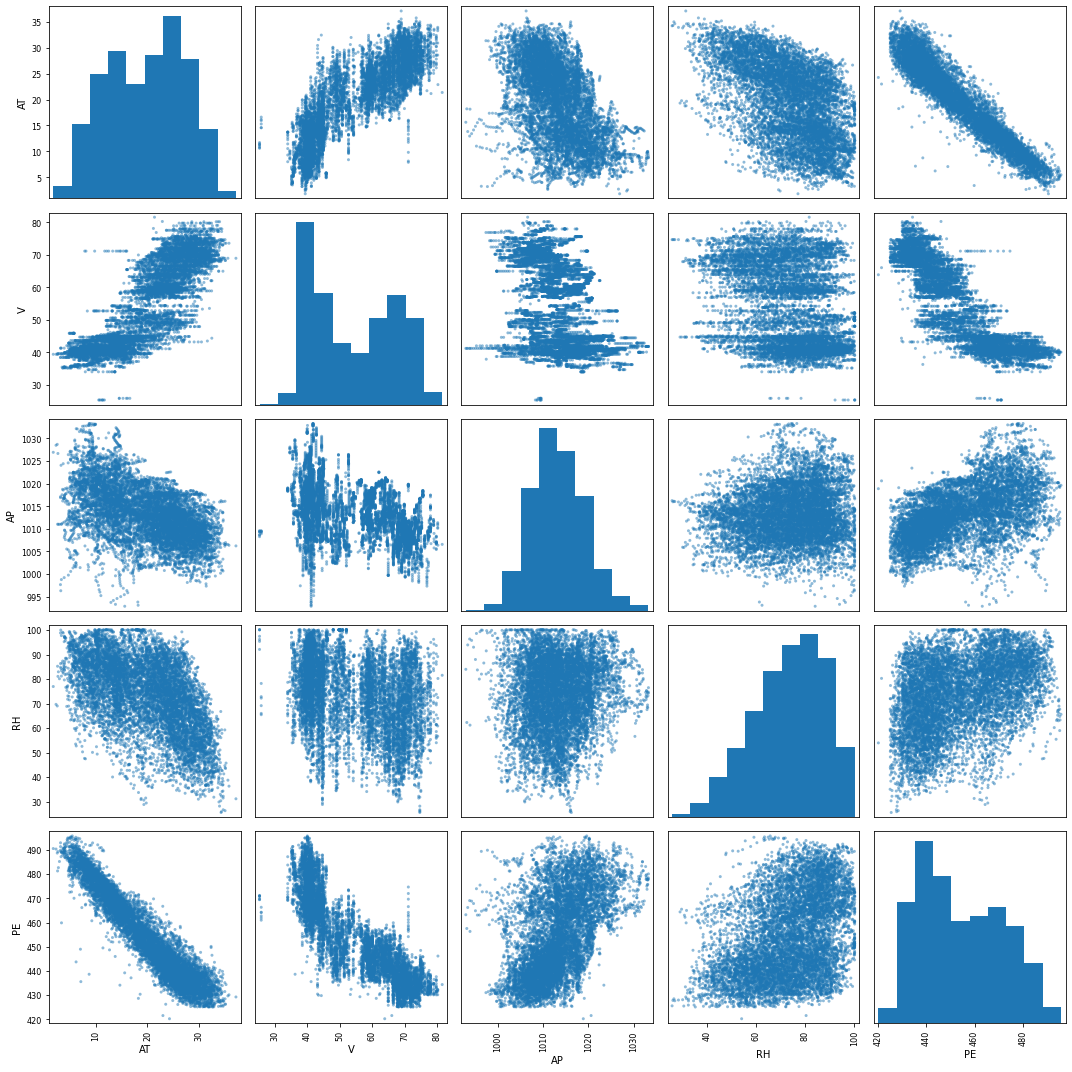

In [6]:
from pandas.plotting import scatter_matrix

scatter_matrix(df, figsize=(15,15),)

plt.tight_layout()
plt.show()

In [7]:
print("From the scatter matrix, EP is strongly related to Temperature (AT) and Exhaust Vacuum (V). As AT and V increase, EP generally decreases. AP and RH also seem to be related to EP, but the relationships are much weaker.")

From the scatter matrix, EP is strongly related to Temperature (AT) and Exhaust Vacuum (V). As AT and V increase, EP generally decreases. AP and RH also seem to be related to EP, but the relationships are much weaker.


In [8]:
output = pd.DataFrame({
    'Mean': df.mean(),
    'Median': df.median(),
    'Min': df.min(),
    'Max': df.max(),
    'Q1': df.quantile(0.25),
    'Q3': df.quantile(0.75)
})

output['Range'] = output['Max'] - output['Min']
output['IQR'] = output['Q3'] - output['Q1']

print(output)

           Mean    Median     Min      Max         Q1       Q3  Range      IQR
AT    19.651231    20.345    1.81    37.11    13.5100    25.72  35.30  12.2100
V     54.305804    52.080   25.36    81.56    41.7400    66.54  56.20  24.8000
AP  1013.259078  1012.940  992.89  1033.30  1009.1000  1017.26  40.41   8.1600
RH    73.308978    74.975   25.56   100.16    63.3275    84.83  74.60  21.5025
PE   454.365009   451.550  420.26   495.76   439.7500   468.43  75.50  28.6800


In [9]:
print("Q_c")

Q_c


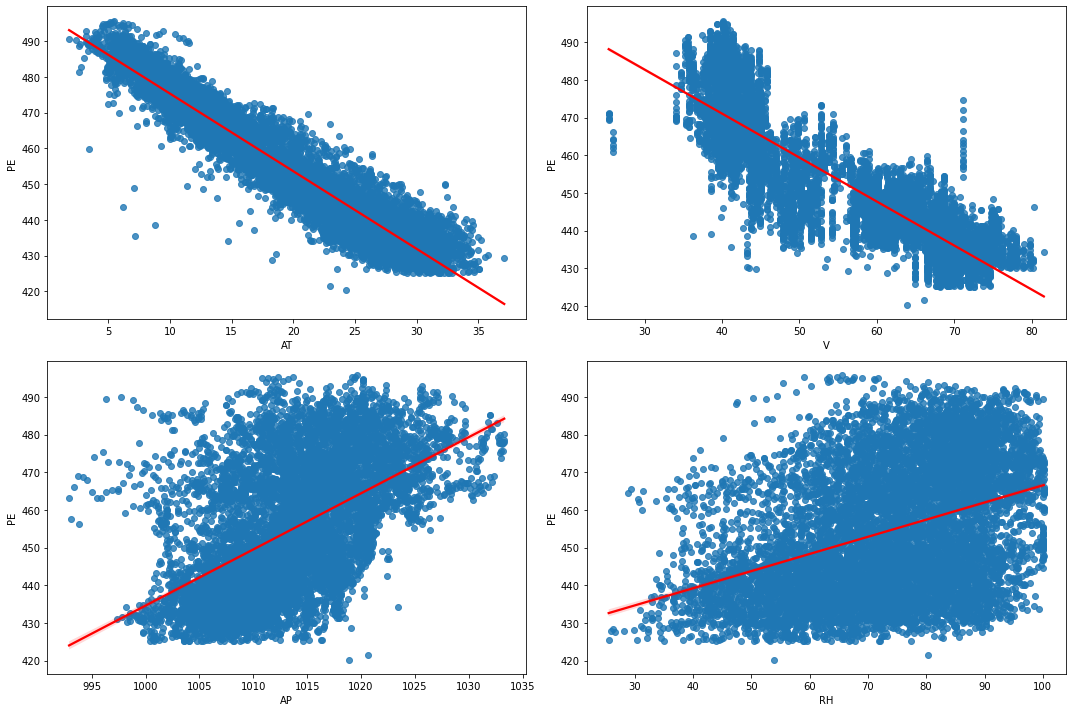

In [10]:
fig, axes = plt.subplots(2,2, figsize=(15,10))

sns.regplot(data=df, x="AT", y="PE", ax=axes[0,0], line_kws={"color":"red"})
sns.regplot(data=df, x="V",  y="PE", ax=axes[0,1], line_kws={"color":"red"})
sns.regplot(data=df, x="AP", y="PE", ax=axes[1,0], line_kws={"color":"red"})
sns.regplot(data=df, x="RH", y="PE", ax=axes[1,1], line_kws={"color":"red"})

plt.tight_layout()
plt.show()

In [11]:
import statsmodels.api as sm

predictors = ["AT", "V", "AP", "RH"]

c_coef = {}

for var in predictors:
    X = sm.add_constant(df[[var]])
    y = df["PE"]
    model = sm.OLS(y, X).fit()
    c_coef[var] = model.params[var]

print(c_coef)

{'AT': -2.1713199585178034, 'V': -1.16813512655571, 'AP': 1.4898716733991135, 'RH': 0.45565010226297975}


In [12]:
print("As shown in the figure, AT and V are negatively related to EP, while AP and RH are positively related to EP. \nAT shows the strongest relationship because most points are close to the regression line. \nAP and RH show weaker relationships with more scattered points. Although there are a few outliers, they are rare and do not affect the overall pattern.")

As shown in the figure, AT and V are negatively related to EP, while AP and RH are positively related to EP. 
AT shows the strongest relationship because most points are close to the regression line. 
AP and RH show weaker relationships with more scattered points. Although there are a few outliers, they are rare and do not affect the overall pattern.


In [13]:
print("Q_d")

Q_d


In [14]:
import statsmodels.api as sm
# Built-in summary method for statsmodels regression models

X = df[["AT", "V", "AP", "RH"]]
y = df["PE"]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Sun, 14 Jun 2026   Prob (F-statistic):               0.00
Time:                        20:54:40   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        454.6093      9.749     46.634      0.0

In [15]:
coef = model.params
print("Coefficient Values:")
print(coef)

intercept = coef["const"]
b1 = coef["AT"]
b2 = coef["V"]
b3 = coef["AP"]
b4 = coef["RH"]

print(f"Regression Equation:")
print(f"PE_hat = {intercept:.4f} + ({b1:.4f}) * AT + ({b2:.4f}) * V + ({b3:.4f}) * AP + ({b4:.4f}) * RH")

Coefficient Values:
const    454.609274
AT        -1.977513
V         -0.233916
AP         0.062083
RH        -0.158054
dtype: float64
Regression Equation:
PE_hat = 454.6093 + (-1.9775) * AT + (-0.2339) * V + (0.0621) * AP + (-0.1581) * RH


In [19]:
print(f"The model is statistically significant p < {a}.")

The model is statistically significant p < 0.05.


In [20]:
a = 0.05
p_vals = model.pvalues

issig = p_vals < a

sig_vars = p_vals[issig].index.tolist()

print(f"\nSignificant predictors p < {a}: {sig_vars}")

print("\nWe fitted a multiple linear regression model with AT, V, AP, and RH as predictors of PE. Since all pvalues are below 0.05, we reject H0:βj=0 for all predictors. Therefore, AT, V, AP, and RH are all significant predictors of PE.")


Significant predictors p < 0.05: ['const', 'AT', 'V', 'AP', 'RH']

We fitted a multiple linear regression model with AT, V, AP, and RH as predictors of PE. Since all pvalues are below 0.05, we reject H0:βj=0 for all predictors. Therefore, AT, V, AP, and RH are all significant predictors of PE.


In [21]:
print("Q_e")

Q_e


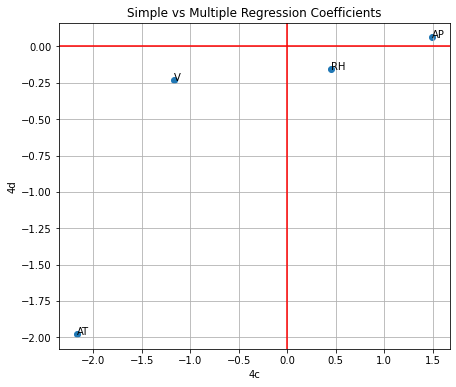

The coefficients change from the simple regression to the multiple regression model. AT is similar, V and AP become smaller, and RH changes sign. This suggests that the predictors are related to each other.


In [22]:
c_coef = {
    'AT': -2.1713199585178034,
    'V': -1.16813512655571,
    'AP': 1.4898716733991135,
    'RH': 0.45565010226297975
}


d_coef = {
    'AT': -1.977513,
    'V': -0.233916,
    'AP': 0.062083,
    'RH': -0.158054
}

predictors = ['AT', 'V', 'AP', 'RH']

x = [c_coef[p] for p in predictors]
y = [d_coef[p] for p in predictors]

plt.figure(figsize=(7, 6))
plt.scatter(x, y)

for p in predictors:plt.text(c_coef[p],d_coef[p],p)

plt.xlabel("4c")
plt.ylabel("4d")
plt.title("Simple vs Multiple Regression Coefficients")
plt.axhline(0, color='red')
plt.axvline(0, color='red')
plt.grid(True)
plt.show()

print("The coefficients change from the simple regression to the multiple regression model. AT is similar, V and AP become smaller, and RH changes sign. This suggests that the predictors are related to each other.")

In [23]:
print("Q_f")

Q_f


In [24]:
X = df[["AT"]].copy()
X["AT2"] = X["AT"] ** 2
X["AT3"] = X["AT"] ** 3
X = sm.add_constant(X)
y = df["PE"]
model = sm.OLS(y, X).fit()
print(model.summary())

X = df[["V"]].copy()
X["V2"] = X["V"] ** 2
X["V3"] = X["V"] ** 3
X = sm.add_constant(X)
y = df["PE"]
model = sm.OLS(y, X).fit()
print(model.summary())

X = df[["AP"]].copy()
X["AP2"] = X["AP"] ** 2
X["AP3"] = X["AP"] ** 3
X = sm.add_constant(X)
y = df["PE"]
model = sm.OLS(y, X).fit()
print(model.summary())

X = df[["RH"]].copy()
X["RH2"] = X["RH"] ** 2
X["RH3"] = X["RH"] ** 3
X = sm.add_constant(X)
y = df["PE"]
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.912
Model:                            OLS   Adj. R-squared:                  0.912
Method:                 Least Squares   F-statistic:                 3.299e+04
Date:                Sun, 14 Jun 2026   Prob (F-statistic):               0.00
Time:                        20:56:33   Log-Likelihood:                -29101.
No. Observations:                9568   AIC:                         5.821e+04
Df Residuals:                    9564   BIC:                         5.824e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        492.7281      0.673    732.248      0.0

In [25]:
print("There is evidence of nonlinear association for all four predictors. For AT, AP and RH, both squared and cubic terms are significant. For V, only the cubic term is significant. Thus, all predictors have a nonlinear relationship with PE.")

There is evidence of nonlinear association for all four predictors. For AT, AP and RH, both squared and cubic terms are significant. For V, only the cubic term is significant. Thus, all predictors have a nonlinear relationship with PE.


In [26]:
print("Q_g")

Q_g


In [27]:
import statsmodels.formula.api as smf
# Build regression model with main effects and all two-way interactions
model = smf.ols("PE ~ (AT + V + AP + RH)**2", data=df).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Sun, 14 Jun 2026   Prob (F-statistic):               0.00
Time:                        20:56:38   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    685.7825     78.640      8.721      0.0

In [28]:
print("Yes, there is evidence of interaction effects. \nAT:V, AT:RH, V:AP, and AP:RH are significant (p < 0.05), while AT:AP and V:RH are not significant. This suggests that some predictors interact with each other in predicting PE.")

Yes, there is evidence of interaction effects. 
AT:V, AT:RH, V:AP, and AP:RH are significant (p < 0.05), while AT:AP and V:RH are not significant. This suggests that some predictors interact with each other in predicting PE.


In [29]:
print("Q_h")

Q_h


In [30]:
from sklearn.model_selection import train_test_split

X = df[["AT","V","AP","RH"]]
y = df["PE"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=1
)

In [31]:
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression

linear = LinearRegression()

linear.fit(X_train, y_train)

train_pred = linear.predict(X_train)
test_pred = linear.predict(X_test)

train_mse1 = mean_squared_error(y_train, train_pred)
test_mse1 = mean_squared_error(y_test, test_pred)

print(f"train_mse1 = {train_mse1}, test_mse1 = {test_mse1}")

train_mse1 = 20.766119761450934, test_mse1 = 20.777478106884395


In [32]:
X2 = df.copy()

X2["AT2"] = X2["AT"]**2
X2["AP2"] = X2["AP"]**2
X2["RH2"] = X2["RH"]**2

X2["AT_V"] = X2["AT"]*X2["V"]
X2["AT_RH"] = X2["AT"]*X2["RH"]
X2["V_AP"] = X2["V"]*X2["AP"]
X2["AP_RH"] = X2["AP"]*X2["RH"]

features = [
    "AT","V","AP","RH",
    "AT2","AP2","RH2",
    "AT_V","AT_RH","V_AP","AP_RH"]

In [33]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2[features],
    y,
    test_size=0.3,
    random_state=1
)

linear2 = LinearRegression()

linear2.fit(X_train2, y_train2)

train_pred2 = linear2.predict(X_train2)
test_pred2 = linear2.predict(X_test2)

train_mse2 = mean_squared_error(y_train2, train_pred2)
test_mse2 = mean_squared_error(y_test2, test_pred2)

print(f"train_mse2 = {train_mse2}, test_mse2 = {test_mse2}")

train_mse2 = 18.063666915213652, test_mse2 = 18.23222576747029


In [34]:
print("Q_i")

Q_i


In [35]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
# raw features
train_mse_raw = []
test_mse_raw = []

k_values = range(1,101)

for k in k_values:

    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    train_pred = knn.predict(X_train)
    test_pred = knn.predict(X_test)
    train_mse_raw.append(mean_squared_error(y_train, train_pred))
    test_mse_raw.append(mean_squared_error(y_test, test_pred))

In [36]:
from sklearn.preprocessing import StandardScaler
import numpy as np
# normalized features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

train_mse_scaled = []
test_mse_scaled = []

for k in k_values:

    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    train_pred = knn.predict(X_train_scaled)
    test_pred = knn.predict(X_test_scaled)
    train_mse_scaled.append(mean_squared_error(y_train, train_pred))
    test_mse_scaled.append(mean_squared_error(y_test, test_pred))

In [37]:
best_k_raw = k_values[np.argmin(test_mse_raw)]
best_test_raw = min(test_mse_raw)

print(f"best_k_raw = {best_k_raw}")
print(f"best_test_raw = {best_test_raw}")

best_k_scaled = k_values[np.argmin(test_mse_scaled)]
best_test_scaled = min(test_mse_scaled)

print(f"best_k_scaled = {best_k_scaled}")
print(f"best_test_scaled = {best_test_scaled}")

best_k_raw = 5
best_test_raw = 15.704821203761764
best_k_scaled = 4
best_test_scaled = 14.070606067136888


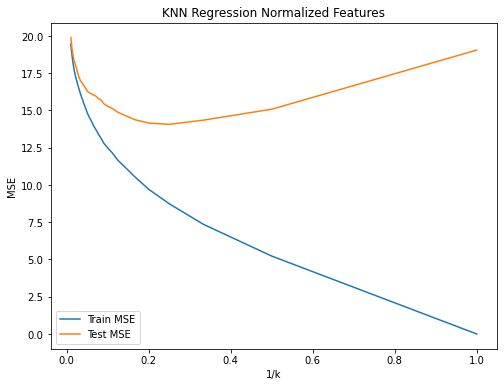

In [38]:
inv_k = 1 / np.array(list(k_values))

plt.figure(figsize=(8,6))

plt.plot(inv_k, train_mse_scaled, label="Train MSE")
plt.plot(inv_k, test_mse_scaled, label="Test MSE")

plt.xlabel("1/k")
plt.ylabel("MSE")
plt.title("KNN Regression Normalized Features")
plt.legend()

plt.show()

In [39]:
print("Q_j")

Q_j


In [40]:
print("The best KNN model (normalized features, k=4) achieved the lowest test MSE (14.07). This is better than both linear regression models. Therefore, KNN performs best on this dataset and can capture nonlinear patterns more effectively.")

The best KNN model (normalized features, k=4) achieved the lowest test MSE (14.07). This is better than both linear regression models. Therefore, KNN performs best on this dataset and can capture nonlinear patterns more effectively.
